# Assignment 2: APIs, Data Formats, Databases, and EDA
## Prepared by Daniil Ruzhinskii

### Python Programming for Business Intelligence
---

## Statement of use of AI

Chat GPT was used in the following interactions:

- to assist with LSEG Api prep for the Task 0 and troubleshooting the outputs.

- to help with the API documentation of Marketstack. In part c) of task 2 I also consulted with chat gpt what would be the most verbose way to approach the task to avoid unnecessary code.

- to check the SQL query with column names as output

- in task 4 to format the x axis of the line plot with the daily interval and changing date decomposition

- in task 7 to identify proper usage of %%time function and if the more verbose code could be produced for the chained merges and computation of the total revenue per category. 


## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

#### a) LSEG / Refinitiv API

I have chosen the source of data LSEG API. LSEG provides the wide variety of the financial api solutions. In this case, I will be using LSEG Data Library (formerly Refinitiv Data Library)

API Documentation is hidden in the developer community and is complex as Refinitiv Data Library (legacy) is still accessible and running, while the next gen LSEG Data Library is as well up and running.

I plan to use interchangeably Refinitiv Data Library and LSEG Data Library as the data availability depends on the asset identifier, meaning one can get more data from either libraries.

For documentation please refer to:
- LSEG Data Library - https://cdn.refinitiv.com/public/lseg-lib-python-doc/2.0.0.2/book/en/index.html
- Refinitiv Data Library - https://cdn.refinitiv.com/public/rd-lib-python-doc/1.0.0.0/book/en/index.html


#### b) Description of the data library

It might be a bit problematic to describe all data offering of LSEG in one markdown cell.

If one is patient enough, one can extract the high coverage of financial instrument data. Equities, Bonds, Derivatives are among the standard instruments data is provided for. 

LSEG is used both in consulting, audit, quantitative analytics, trading and numerous other applications.

I will give the example of the universe search of the Finnish plain vanilla bond and what fields one can extract. I checked quickly that all together there are hundreds (maybe even thousands) of fields available for the financial instruments, one has to be patient to try and test whcih fields yield the valid data for the particular instrument. I will shortlist the selection to those I always use and which give frequently the data.

**Problem is, depending on the query times, LSEG may "hide" the data, and the API requests are not stable to provide data in the fields in repetitive iterations.**

Most standard fields from the table one would consider as a starting point are:
- Instrument (search identity of the security)
- Bond RIC (bond specific LSEG identifier RIC)
- Bid price
- Ask price
- Bid yield
- Ask yield
- Currency

I hide my LSEG API within the .env. One cannot run API without open Refinitiv Workspace.


#####  b.1) Extracting bond prices from LSEG

I tried two separate data extractions - for bond and equities. In this sub-step I present bonds. Like I said, the iterative API calls are not stable via LSEG and one apparently hits the throttling constraints and/or backend breaks down. 

I use the plain vanilla Finnish Government bond identifier, which provides one-to-many relationship when one tries to find the relevant RIC (RIC is the unique Refinitiv identifier, the best search is done with RIC in Refinitiv)

The steps are the following 

1. b.1.1. - open Refinitiv Data Platform session with the hidden API key. Close session
2. b.1.2. - check what RICs are available for this specific bond
3. b.1.3 - shortlist those which actually start with "FI" identity and select only two for testing 
4. b.1.4  - open LSEG Data Library platform to extract the historical time series of requested fields. Close the session.

**b.1.1) Open Refinitiv Data Platform session wiht the hidden API key**

In [3]:
import refinitiv.data as rd
from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

lseg_api = os.environ.get("LSEG_API")

if lseg_api:
    print(f"API Key loaded: {lseg_api[:5]}...")
else:
    print("ERROR: Check the correctness of the .env file)")


API Key loaded: f42c2...


In [31]:
#open session
rd.open_session(app_key=lseg_api)

<refinitiv.data.session.Definition object at 0x11444d8b0 {name='workspace'}>

**b.1.2) check what RICs are available for this specific bond. close session**

In [32]:
bond_rics = rd.get_data(
    universe = ['FI0306758='],
    fields = [
        'TR.BondRIC',
    ]
)
bond_rics

rd.close_session()

**b.1.3) shortlist those which actually start with "FI" identity and select only two for testing**

In [22]:
import re 
finnish_pattern= re.compile(r"^FI")
test_bonds = bond_rics[bond_rics["Bond RIC"].str.contains(finnish_pattern)]
test_bonds = test_bonds.iloc[:10]
test_bonds = test_bonds["Bond RIC"].tolist()
test_bonds

['FI0037635=',
 'FI0037635=CF',
 'FI400003763=2M',
 'FI4000037635=TWEB',
 'FI400003763=RN',
 'FI0037635=FLL',
 'FI4000037635=BPGL',
 'FI4000037635=HVBG',
 'FI4000037635=BAYM',
 'FI4000037635=LUSG']

**b.1.4) open LSEG Data Library platform to extract the historical time series of requested fields. Close the session**

In [23]:
import lseg.data as ld
ld.open_session(app_key=lseg_api)

<lseg.data.session.Definition object at 0x1549f3440 {name='workspace'}>

In [47]:
bond_df =ld.get_history(universe = test_bonds[:2],
          fields = [
               'TR.RIC',          
               'TR.ASKPRICE',
               'TR.BIDPRICE',
               'TRADE_DATE',
               'TR.BIDYIELD',
               'TR.ASKYIELD',
               'TR.FiCurrency'
          ], interval="1M", start="2020-03-01", end="2026-03-31")

/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/lib/python3.12/site-packages/lseg/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future beh

In [118]:
ld.close_session()

#### c) EDA - Explanatory data analysis on the extracted data frame of assets

##### c.1) Preliminary data transformation

First we need to inspect the returned data frame from LSEG.

- Good thing - LSEG naturally returns Pandas data frame object as the response, not JSON. 
- Bad thing - LSEG silently hides the missing values with "empty" rows, meaning the .isna() method is no help for us. 

I check the columns of the df, it is the hierarchical index data frame as we have two-dimensional set-up with two bonds.

In [129]:
# print(bond_df.columns)

I comment out the cell below, but purpose of that one is to inspect the NA status of the RIC column for example bond. It returns "False" for all data values, meaning we have to clean up empty entries and then forward fill with the RIC to complete the data set

In [131]:
# ric_col = bond_df.loc[:, ("FI0037635=", "RIC")]

# print(ric_col.head(10))

# print(ric_col.isna().head(10))

# print(ric_col.astype(str).head(10).tolist())

The purpose of below code cell is to downfill the RIC values per each returned bond. The problem is that LSEG returns "empty" cells which we need to clean up manually before we use the ffill. which expects NA values only

In [215]:
bond_df_long = bond_df.copy() # copy the source df for safety 

for bond in bond_df_long.columns.levels[0]: # we will iterate through the "levels" of the df, ie the bond identifiers 

    col = (bond, "RIC") # this is the bond identiifer - RIC column combination
    #print(col)

    bond_df_long.loc[:, col] = (bond_df_long.loc[:, col] # first locate the specific bond within the hierarchical indices 

        .replace(r"^\s*$", pd.NA, regex=True) # then I use Regex to trace the empty ones and replace with NA object 

        .ffill() # then I just forward fill the RIC 

    )

#Voila, we get the filled in df
#commented out to avoid too much outputs
#bond_df_long.head(-5)

As the resulting DF is the hierarchical index df, we need to **stack it to the long format**. This is the good choice (I think) for the plotting. 

In [216]:
bond_df_long = bond_df_long.stack(level=0).reset_index() #stack the level0 index of bond to the column list. we reset index because indexing changed

bond_df_long = bond_df_long.rename(columns={"level_1": "Bond"}) #rename for descriptiveness

bond_df_long = bond_df_long.iloc[2:] #Omit first two rows becauase these are "metadata" RIC values which we used to downfill the RIC columns

#bond_df_long.head(-5)

/var/folders/23/1vkgpjjn6ng07hrjvnbyb1_00000gn/T/ipykernel_4697/4201224388.py:1:FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


In [132]:
# print(bond_df_long.shape)
# bond_df_long.columns

##### c.2) EDA Starts here

**1) NA summary on the formatted DF**

In [217]:
import pandas as pd

na_summary = pd.DataFrame({
    "NaN": [bond_df_long[col].isna().sum() for col in bond_df_long.columns],
}, index=bond_df_long.columns)

display(na_summary)


,NaN
Date,0
Bond,0
RIC,0
Ask Price,6
Bid Price,6
Bid Yield,6
Ask Yield,6
Currency,6


**2) Describe method on the formatted df**

In [218]:
#compute additional statistics of Mid Price = (Bid + Ask) / 2

bond_df_long["Mid Price"] = (bond_df_long["Bid Price"] + bond_df_long["Ask Price"]) / 2
bond_df_long.describe()

,Date,Ask Price,Bid Price,Bid Yield,Ask Yield,Mid Price
count,152,146.0,146.0,146.0,146.0,146.0
mean,2023-04-02 17:22:06.315789568,108.848479,108.735911,1.453495,1.4287,108.792195
min,2020-03-31 00:00:00,98.163,98.043,-0.581,-0.592,98.103
25%,2021-09-22 12:00:00,100.799,100.763,-0.247,-0.25925,100.781
50%,2023-04-14 00:00:00,101.9445,101.8715,2.1208,2.0889,101.908
75%,2024-10-07 18:00:00,121.25825,121.15825,2.54225,2.5325,121.20825
max,2026-03-31 00:00:00,126.259,126.158,3.199,3.171,126.2085
std,NaN,10.346955,10.35626,1.340077,1.330799,10.35158


**3) KDE plot on the MID price per each bond**

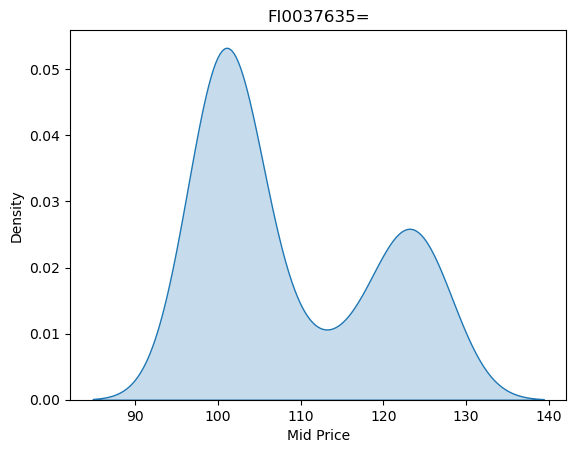

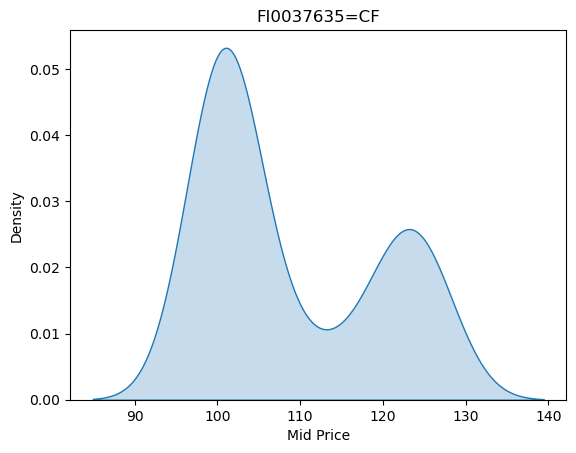

In [219]:
df_plot = bond_df_long.dropna(subset=["Mid Price"]) #subset for only non-NA mid prices
df_bond1 = df_plot[df_plot["Bond"] == "FI0037635="] #separate df for bond1
df_bond2 = df_plot[df_plot["Bond"] == "FI0037635=CF"] #separate df for bond2

import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_bond1["Mid Price"], fill=True) #distribution of Mid price for bond1
plt.title("FI0037635=")
plt.show()

sns.kdeplot(df_bond2["Mid Price"], fill=True) #distribution of Mid price for bond2
plt.title("FI0037635=CF")
plt.show()

**4) Time series line plot for hte bond price dynamics**

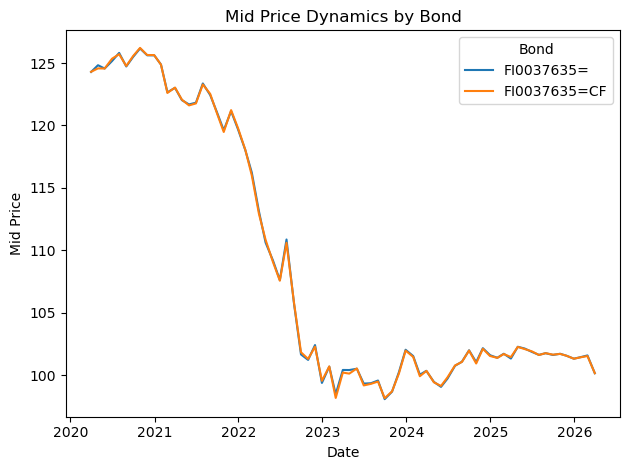

In [220]:
sns.lineplot( data=df_plot, x="Date", y="Mid Price", hue="Bond")
plt.title("Mid Price Dynamics by Bond")
plt.xlabel("Date")
plt.ylabel("Mid Price")

plt.tight_layout()
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [142]:
from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

api_key = os.environ.get("MARKETSTACK_API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:5]}...")
else:
    print("ERROR: Check the .env file ")

Key loaded: 8c100...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [143]:
#a) 
import requests
import json 
api_link = "https://api.marketstack.com/v1/eod"

stock_list = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

date_from = "2026-03-01"
date_to = "2026-03-31"

params = {
    "access_key" : api_key,
    "symbols" : ",".join(stock_list),
    "date_from" : date_from,
    "date_to" : date_to
}

response = requests.get(api_link, params=params)
if response.status_code == 200:
    data = response.json() #we need to convert the response to json format before we can use it
    print(data)
else:
    print(f"Error: {response.status_code} - {response.text}")


{'pagination': {'limit': 100, 'offset': 0, 'count': 100, 'total': 100}, 'data': [{'open': 247.89, 'high': 255.48, 'low': 247.101, 'close': 253.79, 'volume': 48770963.0, 'adj_high': 255.48, 'adj_low': 247.101, 'adj_close': 253.79, 'adj_open': 247.91, 'adj_volume': 49598091.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 204.875, 'high': 210.28, 'low': 204.14, 'close': 208.27, 'volume': 57843337.0, 'adj_high': 210.28, 'adj_low': 204.14, 'adj_close': 208.27, 'adj_open': 204.845, 'adj_volume': 58470078.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AMZN', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 277.84, 'high': 287.05, 'low': 276.81, 'close': 286.86, 'volume': 30680107.0, 'adj_high': 287.05, 'adj_low': 276.76, 'adj_close': 286.86, 'adj_open': 277.54, 'adj_volume': 31625057.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'

In [144]:
#b) 

#There is no meta data apart from pagination
import pandas as pd
stock_data = pd.json_normalize(data,
                                record_path=['data']
                               )

stock_data.head(5)



,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


I am not going to use the simple .describe() method in c) because aggregate function would allow me to choose the stats I need and also append straight away the open and close of the month prices to compute returns 

In [145]:
#c)

stock_data['date'] = pd.to_datetime(stock_data['date'])
stock_data_sorted = stock_data.sort_values(["symbol", "date"]) #sorting to then apply first and last stats

#here using the method agg to apply multiple functions to the close column, and then resetting the index to get a clean dataframe
stock_summary = stock_data_sorted.groupby("symbol")['close'].agg(
    
    count = "count",
    mean = "mean",
    min = "min",
    median = "median",
    max = "max",
    first_close = "first",
    last_close="last").reset_index()

#compute month returns
stock_summary["return_pct"] = (
    (stock_summary["last_close"] - stock_summary["first_close"]) / stock_summary["first_close"]
) * 100

display(stock_summary)

#printout loser and winner
best_stock = stock_summary.sort_values("return_pct", ascending=False).iloc[0]
worst_stock = stock_summary.sort_values("return_pct", ascending=True).iloc[0]

print(f"Best performing stock: {best_stock.name} with return {best_stock['return_pct']:.2f}%")
print(f"Worst performing stock: {worst_stock.name} with return {worst_stock['return_pct']:.2f}%")

,symbol,count,mean,min,median,max,first_close,last_close,return_pct
0,AAPL,20,253.9735,246.63,252.855,262.52,262.52,253.79,-3.325461
1,AMZN,20,210.1385,199.34,210.005,218.94,216.82,208.27,-3.943363
2,GOOG,20,297.2825,273.14,301.185,309.41,303.45,286.86,-5.467128
3,META,20,611.0580,525.72,614.695,667.73,667.73,572.13,-14.317164
4,NFLX,20,94.8445,90.92,94.530,99.17,98.66,96.15,-2.544091


Best performing stock: 4 with return -2.54%
Worst performing stock: 3 with return -14.32%


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

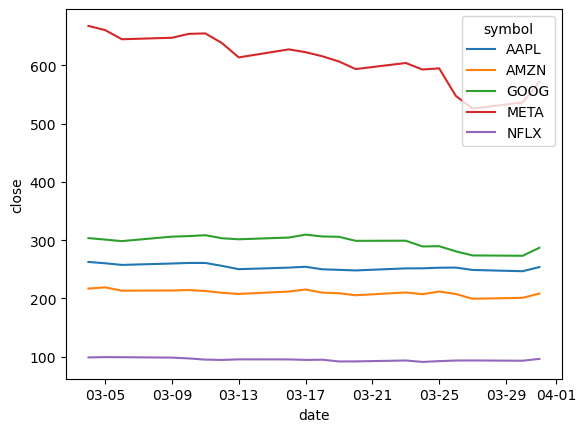

In [146]:
#a)

import seaborn as sns

line_plot = sns.lineplot(data=stock_data, x="date", y="close", hue="symbol")

#I decided to format the x-axis to show only the day and month, as the year is the same for all data points and it would be redundant to show it
import matplotlib.dates as mdates
line_plot.axes.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))


<Axes: xlabel='symbol', ylabel='return_pct'>

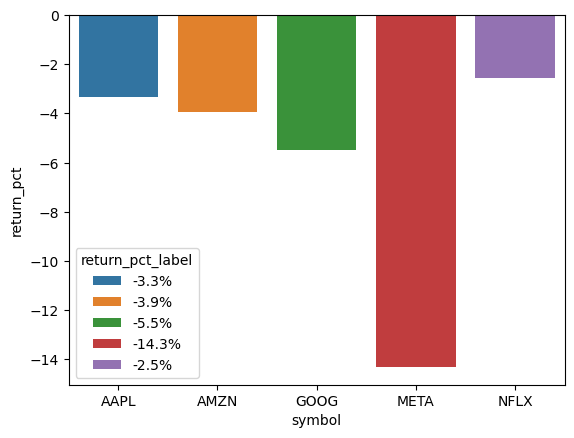

In [147]:
#b)
#i modify the return_pct column to truncte decimals
plot_returns_df = stock_summary.copy()
plot_returns_df["return_pct_label"] = plot_returns_df["return_pct"].map(lambda x: f"{x:.1f}%")

returns_plot = sns.barplot(data=plot_returns_df, x="symbol", y="return_pct", hue="return_pct_label")
returns_plot

In [210]:
#c)

#first have to create a df for a heatmap in pivot format
heatmap_df = stock_data[['symbol', 'date','volume']]

#formatting the date to truncate the long expression
heatmap_df['date'] = pd.to_datetime(heatmap_df['date']).dt.strftime('%m-%d')

heatmap_df = pd.pivot(heatmap_df,
    index= 'symbol',
    columns='date',
    values='volume')

/var/folders/23/1vkgpjjn6ng07hrjvnbyb1_00000gn/T/ipykernel_4697/740984552.py:7:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


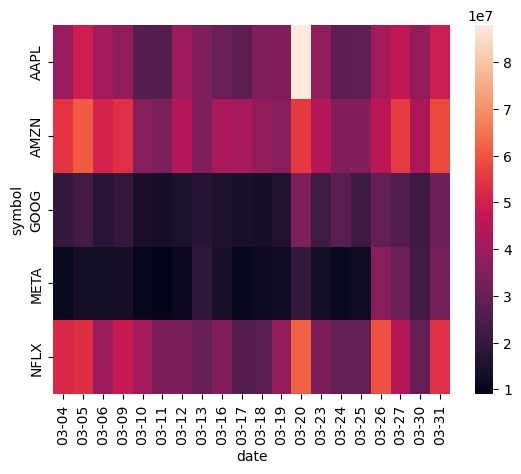

In [211]:
heatmap = sns.heatmap(heatmap_df)

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [222]:
#a)
import os
os.makedirs("exports", exist_ok=True) #create exports folder if it doesn't exist

with open("exports/stockdata.json", "w") as f:
    json.dump(data, f, indent=2)

print("Stock data exported to exports/stockdata.json")

Stock data exported to exports/stockdata.json


In [223]:
#b)
stock_data.to_csv("exports/stockdata.csv", index=False)
print("Stock data exported to exports/stockdata.csv")

Stock data exported to exports/stockdata.csv


In [224]:
#c)
with open("exports/stockdata.json", "r") as f:
    loaded_data = json.load(f)

if loaded_data == data:
    print("Data loaded with json successfully and matches the original data.")
else:    
    print("Error: Loaded data does not match the original data.")

Data loaded with json successfully and matches the original data.


In [225]:
#please note that here I refer to the not-sorted df
#in task 2c i did the sort by date to then apply the first and last functions to returns
loaded_csv = pd.read_csv("exports/stockdata.csv", index_col=False)

display(loaded_csv.head(5)) #loaded data 

display(stock_data.head(5)) #orig

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

#### a)

In [226]:
#a)
import sqlite3

connection = sqlite3.connect("northwind.db")
db = connection.cursor()

db.execute(
    "SELECT name from sqlite_master WHERE type='table';"
)

tables = db.fetchall()

for table in tables:
    print(table[0])



Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


#### b)

In [227]:
#b)

query = "SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30"

#more convenient to use pandas straight away to read the sql query
products = pd.read_sql_query(query, connection)

display(products.head(5))

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.0,6
1,Mishi Kobe Niku,97.0,29
2,Ikura,31.0,31
3,Queso Manchego La Pastora,38.0,86
4,Alice Mutton,39.0,0


#### c)

I first inspect the columns in the tables in question to check the join keys.

Only orders and order_details tables contain the OrderId. Will have to join the customers table on CustomerID with orders first. 

Cell is commented out to avoid residual outputs, but uncomment to check the output to make sure. 

In [228]:
# tables = ["Orders", "Customers", "Order Details"]
# orders_columns = []
# customers_columns = []
# order_details_columns = []

# for table in tables:
#     cols = db.execute(f"PRAGMA table_info('{table}')").fetchall()
#     for col in cols:
#         if table == "Orders":
#             orders_columns.append(col[1])
#         elif table == "Customers":
#             customers_columns.append(col[1])
#         elif table == "Order Details":
#             order_details_columns.append(col[1])

# print(f"Orders columns: {orders_columns}")
# print(f"Customers columns: {customers_columns}")
# print(f"Order Details columns: {order_details_columns}")


In [229]:
#c)
query = """
SELECT c.CompanyName, 
        o.OrderID, 
        o.OrderDate, 
        o.ShipCountry, 
        (od.UnitPrice * od.Quantity) AS LineTotal
FROM Customers c JOIN Orders o ON c.CustomerID = o.CustomerID
JOIN [Order Details] od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""

german_orders = pd.read_sql_query(query, connection)

display(german_orders.head(5))

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

#### a)

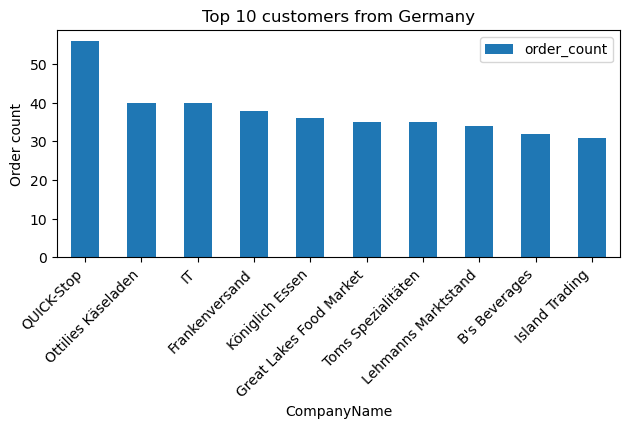

In [230]:
#a)
import matplotlib.pyplot as plt

#create a unique count of orders based on OrderID
top_10_customers = german_orders.groupby("CompanyName")["OrderID"].nunique()

#define the new column name for the recently created count of orders
top_10_customers = top_10_customers.reset_index(name="order_count")

#sort the df and choose maximum 10
top_10_customers = top_10_customers.sort_values("order_count", ascending=False).head(10)

#set the index as company names to pass the df expected in bar plot

top_10_customers = top_10_customers.set_index("CompanyName")

#creating a plot 
top_10_customers.plot.bar() #definition of bar plot
plt.ylabel("Order count") #y axis
plt.title("Top 10 customers from Germany") #title
plt.tight_layout() 
plt.xticks(rotation=45, ha="right")  # important for readability
plt.show()

#### b)

In [232]:
#b) 

#we have to transform the order date to omit the hours and minutes, otherwise the result will be too granular for plot
sales_per_date = german_orders.copy()

sales_per_date["OrderDate"] = pd.to_datetime(sales_per_date["OrderDate"],format="mixed").dt.strftime("%Y-%m-%d")
sales_per_date = sales_per_date.groupby('OrderDate')['LineTotal'].sum()

sales_per_date = sales_per_date.reset_index(name='Total')

#sales_per_date

<Axes: xlabel='Total', ylabel='Density'>

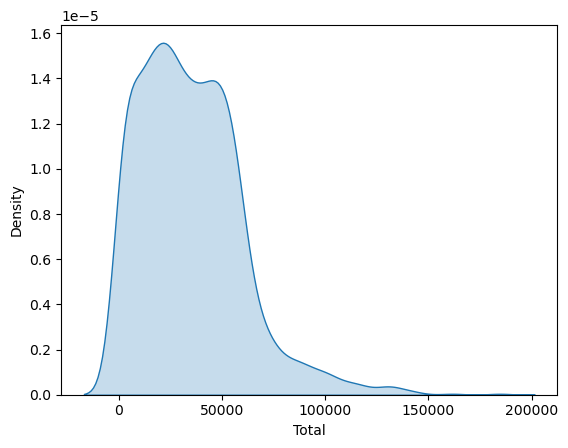

In [233]:
sns.kdeplot(data=sales_per_date, x='Total', fill=True)

#### c)

Again, in order to join I need to first inspect the available columns to identify the potential join keys. I commented out the cell to avoid residual output



In [ ]:
#c)
# query = "SELECT * FROM 'Order Details'"
# order_details= pd.read_sql_query(query, connection)
# order_details_cols = order_details.columns.tolist()
# print(f"OrderDetails columns: {order_details_cols}")

# query = "SELECT * FROM Products"
# products = pd.read_sql_query(query, connection)
# products_cols = products.columns.tolist()
# print(f"Products columns: {products_cols}")

# query = "SELECT * FROM Categories"
# categories = pd.read_sql_query(query, connection)
# categories_cols = categories.columns.tolist()
# print(f"Categories columns: {categories_cols}")

In [234]:
#c)

import time 
start = time.time()
query = """
SELECT cat.CategoryName,
        SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od 
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
"""
# reminder for myself: always use GROUP BY when we have 
# an aggregate function like SUM
category_revenue_sql = pd.read_sql_query(query, connection)
end = time.time()
sql_execution_time = end - start

print(f"SQL Execution time: {sql_execution_time:.4f} seconds")
display(category_revenue_sql)


SQL Execution time: 0.5113 seconds


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [235]:
#a)
query = "SELECT * FROM Products"
products = pd.read_sql_query(query, connection)

query= "SELECT * FROM Categories"
categories = pd.read_sql_query(query, connection)

display(products.head(5))
display(categories.head(5))

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [236]:
#b)
merged_df = pd.merge(products, categories, left_on="CategoryID", right_on="CategoryID", how="inner")

I consulted with AI regarding the replication of SQL result using pandas chained merges and creation of the new column separately. It is possible to implement it in the one single function with nested functions, but I decided to separate them for clarify and readability of the code 

In [237]:
#c)

#chained merges
#pandas produces the duplicate columns after joins
#Important: join keys are not affected, only matching columns are duplicated

#I use suffixes to track the duplicate columns

start = time.time()
query = "SELECT * FROM 'Order Details'"
order_details= pd.read_sql_query(query, connection)

query = "SELECT * FROM Products"
products = pd.read_sql_query(query, connection)

query = "SELECT * FROM Categories"
categories = pd.read_sql_query(query, connection)


merged_df = pd.merge(order_details, products, left_on="ProductID", 
                     right_on="ProductID", 
                     how="inner", suffixes=("", "_prod"))

merged_df = pd.merge(merged_df, categories, left_on="CategoryID", 
                     right_on="CategoryID", 
                     how="inner", suffixes=("", "_cat"))



#new TotalRevenue column
merged_df["TotalRevenue"] = merged_df["UnitPrice"] * merged_df["Quantity"]

category_revenue_pd = (
    merged_df.groupby("CategoryName", as_index=False)["TotalRevenue"]
    .sum()
)
end = time.time()
pandas_execution_time = end - start
print(f"Pandas Execution time: {pandas_execution_time:.4f} seconds")


time_difference = sql_execution_time-pandas_execution_time
print(f"Time difference (SQL - Pandas): {time_difference:.4f} seconds")


# uncomment to make sure that dfs are identical if needed
# if category_revenue_sql.equals(category_revenue_pd):
#     print("Pandas and SQL results match!")
# else:
#     print("Error: Pandas and SQL results do not match.")

Pandas Execution time: 1.4459 seconds
Time difference (SQL - Pandas): -0.9346 seconds


### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [238]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})


In [239]:
#a)
#melt = from wide to long 
display(wide_data)
wide_data_melted = pd.melt(wide_data,
                            id_vars = "store",
                            var_name = "quarter",
                            value_name = "sales")

display(wide_data_melted)

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [240]:
#b)
display(long_data)
#pivot = from long to wide 
long_data_pivoted = long_data.pivot(
                                index="month",
                                columns="product",
                                values="units_sold"
).reset_index() #reset index to get month back as a column
#is is necessary here, otherwie will have month as index and not a column

display(long_data_pivoted)

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [241]:
#c)

#reverting back to the original wide df

wide_data_reverted = wide_data_melted.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

display(wide_data_reverted)
display(wide_data)


#reverting back to the original long df
month_order = ["Jan", "Feb", "Mar"]
long_data_reverted = long_data_pivoted.melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold").sort_values(["month"])

#first set the updated indices
long_data_reverted["month"] = pd.Categorical(long_data_reverted["month"], categories=month_order,
                                            ordered=True)

#reset indices by sorting
long_data_reverted = long_data_reverted.sort_values("month").reset_index(drop=True)

display(long_data_reverted)
display(long_data)


quarter,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130
